In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import  pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:

telcom = pd.read_csv("/content/drive/MyDrive/Telcom Customer Churn Project/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:

telcom.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:

# Checking Duplictes
telcom.duplicated().sum()

np.int64(0)

In [ ]:

# Checking null
telcom.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:

# Change  columns (like SeniorCitizen -> Senior Citizen)
telcom.columns = telcom.columns.str.replace(r'([a-z0-9])([A-Z])', r'\1_\2', regex=True).str.title()


In [ ]:

telcom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer_Id        7043 non-null   object 
 1   Gender             7043 non-null   object 
 2   Senior_Citizen     7043 non-null   int64  
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Tenure             7043 non-null   int64  
 6   Phone_Service      7043 non-null   object 
 7   Multiple_Lines     7043 non-null   object 
 8   Internet_Service   7043 non-null   object 
 9   Online_Security    7043 non-null   object 
 10  Online_Backup      7043 non-null   object 
 11  Device_Protection  7043 non-null   object 
 12  Tech_Support       7043 non-null   object 
 13  Streaming_Tv       7043 non-null   object 
 14  Streaming_Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless_Billing  7043 

In [ ]:

# Checking Unique Values to understand column data and find potential typos
for col in telcom.columns:
    unique_vals = telcom[col].unique()
    print(f"{col}: {unique_vals}\n\n{'-'*30}")

Customer_Id: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

------------------------------
Gender: ['Female' 'Male']

------------------------------
Senior_Citizen: [0 1]

------------------------------
Partner: ['Yes' 'No']

------------------------------
Dependents: ['No' 'Yes']

------------------------------
Tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]

------------------------------
Phone_Service: ['No' 'Yes']

------------------------------
Multiple_Lines: ['No phone service' 'No' 'Yes']

------------------------------
Internet_Service: ['DSL' 'Fiber optic' 'No']

------------------------------
Online_Security: ['No' 'Yes' 'No internet service']

------------------------------
Online_Backup: ['Yes' 'No' 'No internet service']

------------------------------


In [ ]:

# Change the data type from column into integer

telcom['Senior_Citizen'] = telcom['Senior_Citizen'].astype(int)


In [ ]:

# Making This columns into a separate label column with yes and no for easy understanding in chart.

telcom['Senior_Citizen_Status'] = telcom["Senior_Citizen"].map({0:"No", 1:"Yes"})
telcom["Churn_Flag"] = telcom['Churn'].map({"Yes":1, "No":0})

In [ ]:

telcom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_Id            7043 non-null   object 
 1   Gender                 7043 non-null   object 
 2   Senior_Citizen         7043 non-null   int64  
 3   Partner                7043 non-null   object 
 4   Dependents             7043 non-null   object 
 5   Tenure                 7043 non-null   int64  
 6   Phone_Service          7043 non-null   object 
 7   Multiple_Lines         7043 non-null   object 
 8   Internet_Service       7043 non-null   object 
 9   Online_Security        7043 non-null   object 
 10  Online_Backup          7043 non-null   object 
 11  Device_Protection      7043 non-null   object 
 12  Tech_Support           7043 non-null   object 
 13  Streaming_Tv           7043 non-null   object 
 14  Streaming_Movies       7043 non-null   object 
 15  Cont

In [ ]:

telcom['Total_Charges'].astype(float) # There is some blank space

ValueError: could not convert string to float: ' '

In [ ]:

telcom[telcom['Total_Charges']==" "]

,Customer_Id,Gender,Senior_Citizen,Partner,Dependents,Tenure,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,...,Streaming_Tv,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn,Senior_Citizen_Status,Churn_Flag
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No,No,0
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,Two year,No,Mailed check,20.25,,No,No,0
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,Yes,Two year,No,Mailed check,80.85,,No,No,0
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,Two year,No,Mailed check,25.75,,No,No,0
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,No,Two year,No,Credit card (automatic),56.05,,No,No,0
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,Two year,No,Mailed check,19.85,,No,No,0
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,Two year,No,Mailed check,25.35,,No,No,0
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,Two year,No,Mailed check,20.00,,No,No,0
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No,No,0
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,No,Two year,No,Mailed check,73.35,,No,No,0


In [ ]:

## Droping those blank space total chrages because they are in very less number
telcom = telcom[telcom['Total_Charges'] != " "].reset_index(drop = True)
telcom['Total_Charges'] = telcom['Total_Charges'].astype(float)

In [ ]:

# Clean Data
df = telcom

In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_Id            7032 non-null   object 
 1   Gender                 7032 non-null   object 
 2   Senior_Citizen         7032 non-null   int64  
 3   Partner                7032 non-null   object 
 4   Dependents             7032 non-null   object 
 5   Tenure                 7032 non-null   int64  
 6   Phone_Service          7032 non-null   object 
 7   Multiple_Lines         7032 non-null   object 
 8   Internet_Service       7032 non-null   object 
 9   Online_Security        7032 non-null   object 
 10  Online_Backup          7032 non-null   object 
 11  Device_Protection      7032 non-null   object 
 12  Tech_Support           7032 non-null   object 
 13  Streaming_Tv           7032 non-null   object 
 14  Streaming_Movies       7032 non-null   object 
 15  Cont

In [ ]:

df.head()

,Customer_Id,Gender,Senior_Citizen,Partner,Dependents,Tenure,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,...,Streaming_Tv,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn,Senior_Citizen_Status,Churn_Flag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,No,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,No,1


## **EDA**

### **"Overall Customer Churn Rate"**

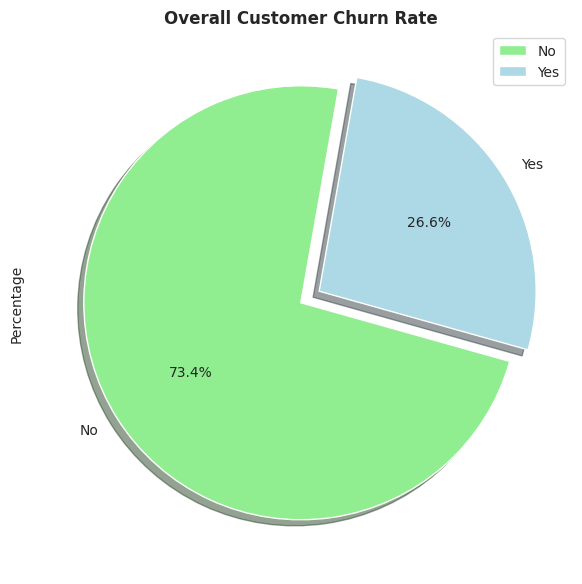

In [ ]:

df['Churn'].value_counts().plot.pie(figsize=(7,8),autopct="%1.1f%%",
                                         colors= ["lightgreen","lightblue"], explode = (0,0.1),startangle = 80, shadow = True)

plt.title("Overall Customer Churn Rate",fontsize = 12,fontweight="bold")
plt.legend(labels = ["No","Yes"])
plt.ylabel("Percentage")
plt.show()

# **1. The Retention Cliff: Analyzing Customer Attrition by Tenure**

Getting a new customer costs time and marketing money. If a customer leaves too quickly, the company loses money on that signup. In this section, we analyze customer Tenure (how many months they stay) against Churn to see exactly when most customers decide to leave.

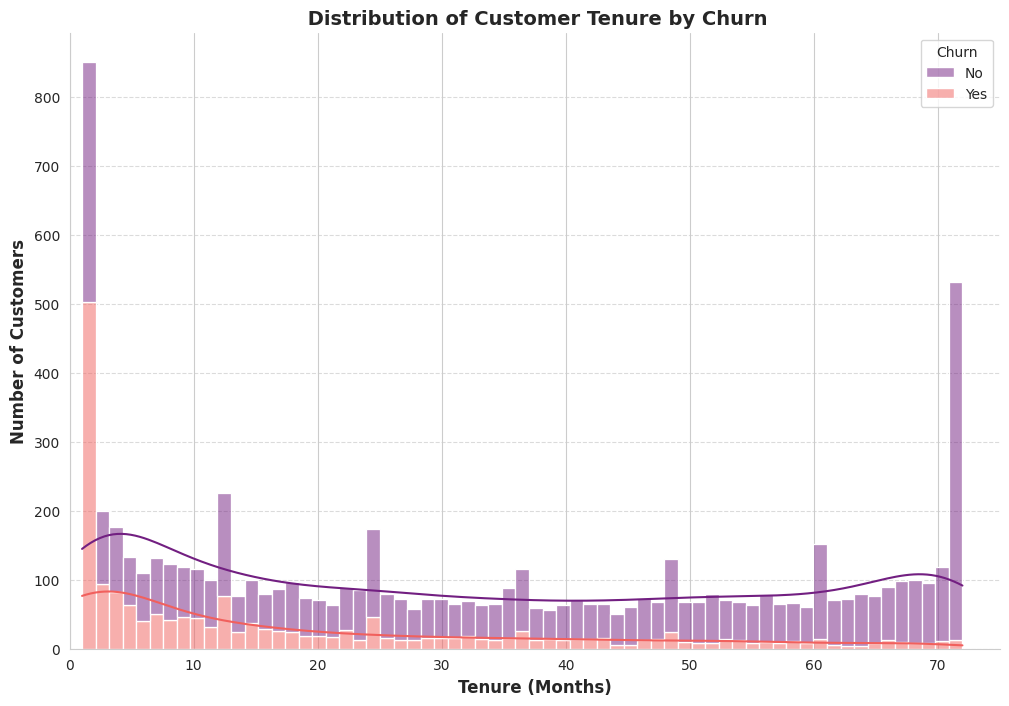

In [ ]:

plt.figure(figsize=(12,8))

# Plot the distribution with a Kernel Density Estimate (KDE) curve
sns.histplot(data=df, x='Tenure', hue='Churn', multiple='stack',
             kde=True, bins=65, palette="magma")

plt.title(' Distribution of Customer Tenure by Churn', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Months)', fontsize=12, fontweight="bold")
plt.ylabel('Number of Customers', fontsize=12, fontweight="bold")
plt.xlim(0, 75)
plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine()


plt.show()

### **Insights**

- **Early Drop-off:** Churn is highest in the first 1 to 5 months. Many customers leave almost immediately after joining.
- **Long-Term Loyalty:** Customers who stay past their first year (12+ months) are far less likely to leave and become very loyal.
- **Business Recommendation:** The company needs to improve the new customer onboarding experience and offer early support or check-ins during the first 90 to 120 days to prevent early cancellations.

# **2. Monthly Charges vs. Churn**

**Problem Statement:** Not every lost customer impacts the company equally. Losing a customer on a cheap plan hurts less than losing a customer paying a premium bill every month. Here, we analyze Monthly Charges against Churn to see whether budget customers or high-paying customers are leaving more often.

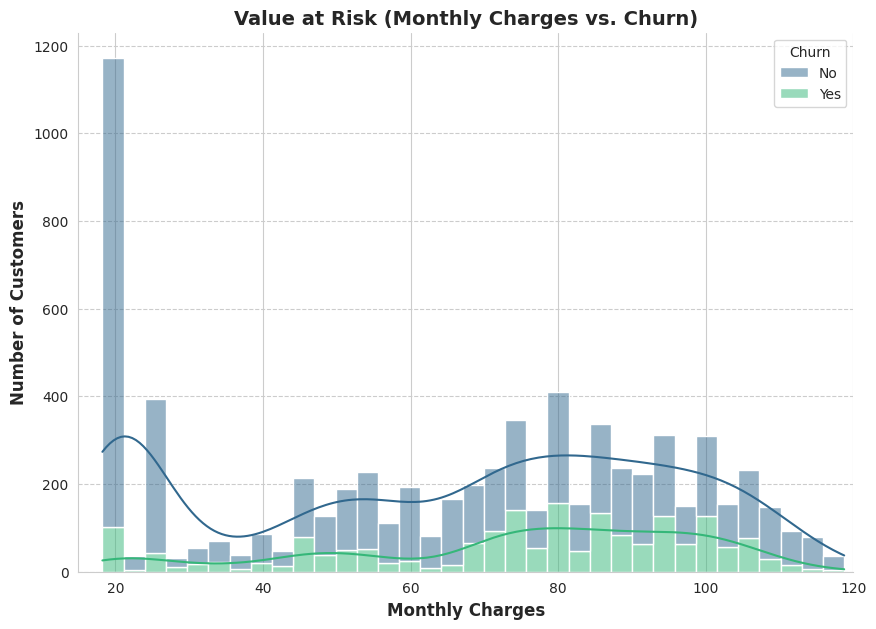

In [ ]:

# Histogram

plt.figure(figsize=(10,7))

sns.histplot(data = df , x= "Monthly_Charges",kde = True, hue="Churn",multiple = "stack",bins = 35,palette = "viridis")

plt.title("Value at Risk (Monthly Charges vs. Churn)",fontsize = 14,fontweight = "bold")
plt.xlabel("Monthly Charges",fontsize = 12,fontweight = "bold")
plt.ylabel("Number of Customers",fontsize = 12,fontweight = "bold")
plt.grid(axis ='y',linestyle = "--")
sns.despine()
plt.xlim(15,120)
plt.show()


In [ ]:

# 1. Filter the dataset to ONLY include people paying between $20 and $30
budget_tier = telcom[(telcom['Monthly_Charges'] >= 20) & (telcom['Monthly_Charges'] <= 30)]

# 2. Calculate the percentage of churn in this specific group
budget_churn_rate = budget_tier['Churn_Flag'].mean() * 100

print(f"Exact Churn Rate for $20-$30 range: {budget_churn_rate:.2f}%")


# 1. Filter the dataset to ONLY include people paying between $20 and $30
budget_tier = telcom[(telcom['Monthly_Charges'] >=75 ) & (telcom['Monthly_Charges'] <= 120)]

# 2. Calculate the exact percentage of churn in this specific group
budget_churn_rate = budget_tier['Churn_Flag'].mean() * 100

print(f"Exact Churn Rate for $75-$120 range: {budget_churn_rate:.2f}%")

Exact Churn Rate for $20-$30 range: 10.33%
Exact Churn Rate for $75-$120 range: 34.67%


### **Insights**

- **Budget Customers are Stable:** Customers paying low monthly bills ($20–$30) have a very low churn rate of **10.33%** and stay loyal.
- **High-Bill Risk:** Churn increases to **34.67%** for customers with higher monthly charges ($75–$120).
- **Business Recommendation:** High-paying customers might feel they are not getting enough value for the price. The company should review the quality of its premium plans or bundle helpful services to make high bills feel worth the cost.

## **2.2 Follow-up Investigation: The "Trapped" Customer Persona (Demographics vs. Price Sensitivity)**

In Question 2, we established a clear rule: high monthly charges mean high churn. But in the real world, human behavior is messy — does that rule apply to everyone?

The effort it takes to switch internet or phone providers matters. If a customer is alone, switching is easy. But with a family relying on multiple devices, streaming accounts, and work-from-home setups, switching providers is a much bigger operational headache.

**Questions:**
- Do customers without dependents churn rapidly when bills get high?
- Do customers with dependents tolerate higher bills simply because the friction of switching is too high?

In [ ]:

df["Billing_Category"] = pd.cut(df['Monthly_Charges'],
                                bins = [0,35,70,120],
                                labels = ['Low','Medium','High']
                                )


Dependent_Churn = df.groupby(['Dependents',"Billing_Category"])["Churn_Flag"].mean().reset_index()

# Change it to percentage

Dependent_Churn["Churn_Percentage"] = Dependent_Churn["Churn_Flag"]*100

Dependent_Churn





/tmp/ipykernel_3779/2066000760.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Dependent_Churn = df.groupby(['Dependents',"Billing_Category"])["Churn_Flag"].mean().reset_index()


,Dependents,Billing_Category,Churn_Flag,Churn_Percentage
0,No,Low,0.141482,14.148219
1,No,Medium,0.274607,27.460711
2,No,High,0.396276,39.627561
3,Yes,Low,0.060870,6.086957
4,Yes,Medium,0.157895,15.789474
5,Yes,High,0.226562,22.656250


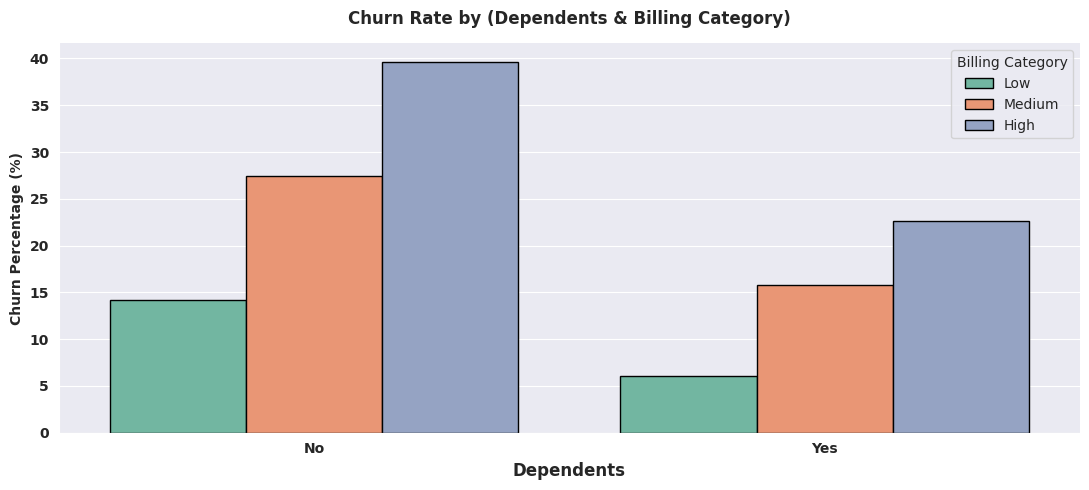

In [ ]:

# Making The Plot


plt.figure(figsize=(11,5))
sns.set_style("darkgrid")


sns.barplot(data = Dependent_Churn , x='Dependents', y='Churn_Percentage',
            hue='Billing_Category', palette='Set2', edgecolor = "black")

plt.title('Churn Rate by (Dependents & Billing Category)', fontsize=12, fontweight='bold', pad=14)
plt.ylabel('Churn Percentage (%)', fontsize=10, fontweight='bold')
plt.xlabel('Dependents', fontsize=12, fontweight='bold')

plt.xticks(fontweight = "bold")
plt.yticks(fontweight = "bold")

plt.legend(title = "Billing Category")
sns.despine()
plt.tight_layout()
plt.show()



### **Insights**

This first look suggests customers without dependents churn faster as bills increase — but `Dependents` alone is an incomplete measure of household complexity, since it ignores whether the customer has a partner.

To get a clearer picture, `Partner` and `Dependents` are combined into a single `Household_Type` (Alone / Couple / Family), and Add-On Count is also checked, since more add-ons could independently explain lower churn regardless of household type.

In [ ]:

# Making a new column that shows the count of add ons customers have

add_on_col = ['Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support',
       'Streaming_Tv', 'Streaming_Movies']


df['Add_On_Count'] = (df[add_on_col]=='Yes').sum(axis =1)

In [ ]:

# Making a Household type col to flag

# No partner + No dependents → Alone
# Partner + No dependents → Couple
# Any dependents (regardless of partner) → Family

conditions = [
    df['Dependents'] == 'Yes',
    (df['Partner'] == 'Yes') & (df['Dependents'] == 'No'),
    (df['Partner'] == 'No') & (df['Dependents'] == 'No')
]

choices = ['Family', 'Couple', 'Alone']

df['Household_Type'] = np.select(conditions, choices, default='Unknown') # Added a default for completeness

# Display the value counts for the new column
df['Household_Type'].value_counts()

,count
Household_Type,
Alone,3280
Family,2099
Couple,1653


In [ ]:

churn_rate_high_billing = df[df['Billing_Category'].isin(['High'])] \
.groupby(['Add_On_Count','Household_Type'])['Churn_Flag'].mean().reset_index()


churn_rate_high_billing['Churn_Percentage'] = churn_rate_high_billing['Churn_Flag'] * 100


In [ ]:

def plot(data,x,y,hue,title,x_label,y_label,legend):

  plt.figure(figsize = (11,5))
  sns.set_style("darkgrid")

  sns.barplot(data = data, x = x, y = y ,hue = hue, palette = "Set2", edgecolor = "black")

  plt.title(title,fontweight = "bold",fontsize = 14, pad = 15)
  plt.xlabel(x_label,fontweight = "bold",fontsize = 12)
  plt.ylabel(y_label,fontweight = "bold",fontsize = 12)

  plt.xticks(fontweight = "bold")
  plt.yticks(fontweight = "bold")

  plt.legend(title = legend)
  sns.despine()

  plt.tight_layout()
  plt.show()

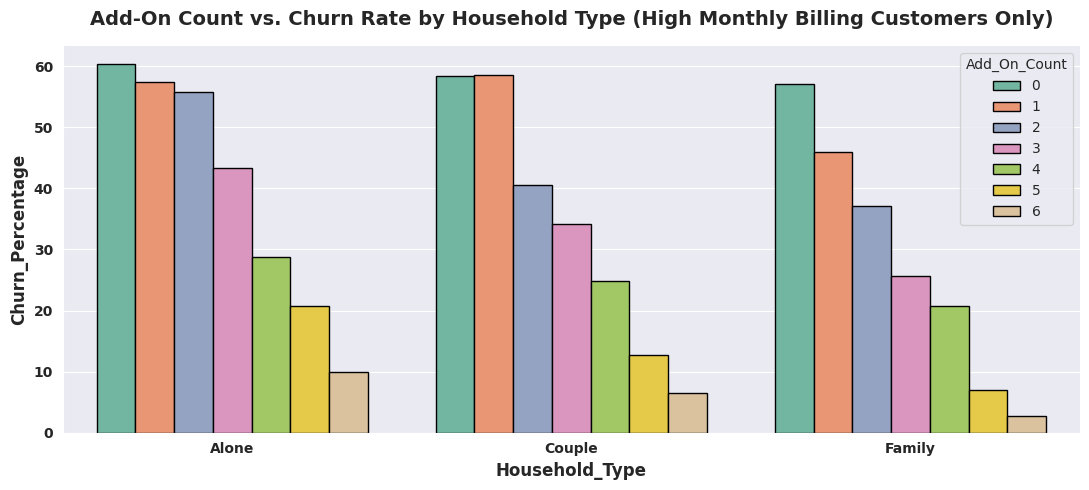

In [ ]:

plot(churn_rate_high_billing ,"Household_Type", "Churn_Percentage", "Add_On_Count",
        "Add-On Count vs. Churn Rate by Household Type (High Monthly Billing Customers Only)",
     "Household_Type", "Churn_Percentage", "Add_On_Count",)

### **Insights**

- **Finding:** Among High-billing customers, churn drops sharply as the number of add-ons increases — from about 57–60% churn with 0 add-ons down to just 3–10% churn with 6 add-ons. This same pattern holds whether the customer is Alone, a Couple, or a Family — household type doesn't meaningfully change the story.
- **So What:** How many add-ons a customer has matters much more than their household type. The real risk group is High-billing customers with few or no add-ons — not "singles" or "families" specifically. *(Note: Add-On Count and Tenure showed a moderate positive correlation of 0.5, so this should be read as a strong association rather than a fully proven independent cause.)*
- **Recommendation:** The company should offer discounted add-on bundles (e.g. Tech Support + Security) to High-billing customers with 0–2 add-ons. This group shows the highest churn risk and the clearest opportunity to reduce it.

# **3. Churn Rate by Contract Type (Month-to-month vs One year vs Two year)**

Does contract length influence customer churn, and if so, by how much? Understanding this relationship helps the company evaluate whether encouraging longer-term contracts could be an effective retention strategy.

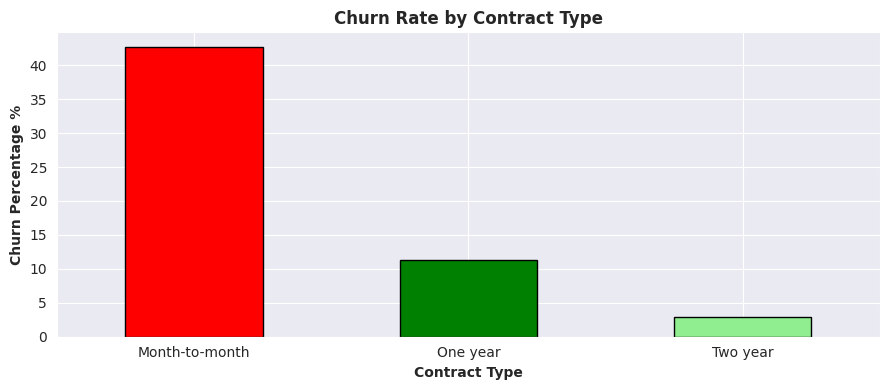

In [ ]:

churn_rate_by_contract = df.groupby("Contract")['Churn_Flag'].mean()*100

plt.figure(figsize=(9,4))
churn_rate_by_contract.plot(kind="bar", color=["red","green","lightgreen"], edgecolor="black")
plt.title("Churn Rate by Contract Type", fontsize=12, fontweight="bold")
plt.xlabel("Contract Type", fontsize=10, fontweight="bold")
plt.ylabel("Churn Percentage %", fontsize=10, fontweight="bold")
plt.xticks(rotation=0)  # keep labels horizontal, easier to read


plt.tight_layout()
plt.show()

### **Insights**

- **Finding:** Month-to-month churn is above ~40%, compared to ~10% for one-year and ~3% for two-year contracts. Contract type shows the largest churn gap of any factor tested so far — this needs further investigation before drawing conclusions about *why*.
- **Business Recommendation:** The company should still prioritize converting month-to-month customers to longer-term contracts through discounts or added perks.

## **3.1 Follow-up Investigation: Does Payment Method Add Further Risk on Top of Contract Type?**

We already found that contract type and internet service both affect churn on their own, and that missing Tech Support explains part of why Fiber optic churns so much.

Now the question is: does combining contract type with payment method reveal an even bigger risk group than either factor alone? Knowing "month-to-month customers churn more" isn't very useful by itself — it's too broad. But if one specific combination shows a churn rate far higher than the rest, that gives the company an exact group to target for retention.

In [ ]:

#Making a group by to see Tenure and Churn Rate for contract type and payment_method

plot_data = df.groupby(["Contract","Payment_Method"])[["Tenure","Churn_Flag"]].mean().reset_index()

plot_data["Churn_Percentage"] = plot_data['Churn_Flag']*100

In [ ]:

plot_data

,Contract,Payment_Method,Tenure,Churn_Flag,Churn_Percentage
0,Month-to-month,Bank transfer (automatic),24.904924,0.341256,34.125637
1,Month-to-month,Credit card (automatic),23.955801,0.327808,32.780847
2,Month-to-month,Electronic check,17.971351,0.537297,53.729730
3,Month-to-month,Mailed check,10.042553,0.315789,31.578947
4,One year,Bank transfer (automatic),46.017903,0.097187,9.718670
5,One year,Credit card (automatic),45.477387,0.103015,10.301508
6,One year,Electronic check,46.178674,0.184438,18.443804
7,One year,Mailed check,29.211310,0.068452,6.845238
8,Two year,Bank transfer (automatic),61.822064,0.033808,3.380783
9,Two year,Credit card (automatic),59.910345,0.022414,2.241379


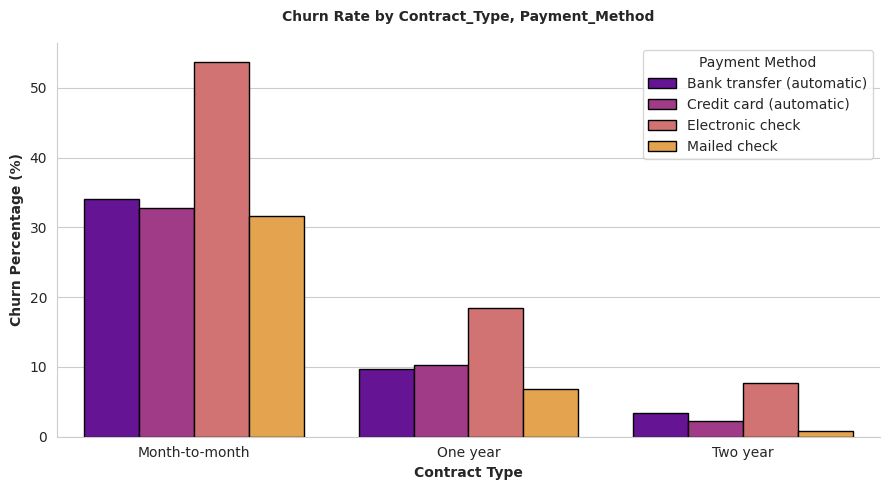

In [ ]:

plt.figure(figsize=(9,5))
sns.set_style("whitegrid")


sns.barplot(data = plot_data, x='Contract', y='Churn_Percentage', hue='Payment_Method', palette='plasma', edgecolor='black')

plt.title('Churn Rate by Contract_Type, Payment_Method', fontsize=10, fontweight='bold', pad=16)
plt.ylabel('Churn Percentage (%)', fontsize=10, fontweight='bold')
plt.xlabel('Contract Type', fontsize=10, fontweight='bold')

plt.legend(title = "Payment Method")
sns.despine()

plt.tight_layout()
plt.show()

### **Insights**

The table shows Electronic check has the highest churn in every contract type, but those customers also tend to have lower average tenure. This makes it unclear whether Electronic check itself is risky, or whether it just looks risky because those customers are newer.

To check this, customers were grouped into tenure ranges (in months), and churn rate was compared by payment method within each range.

In [ ]:

# Create tenure beans

df["Tenure_Group"] = pd.cut(df['Tenure'],
                            bins = [0,12,24,36,48,60,72],
                            labels = ["0-12","12-24","24-36","36-48","48-60","60-72"]
                            )
t_group  = df.groupby(["Tenure_Group","Payment_Method"])[["Churn_Flag"]].mean().reset_index()

# Make it to the percentage

t_group["Churn_Percentage"] = t_group["Churn_Flag"]*100

/tmp/ipykernel_3779/4140385424.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  t_group  = df.groupby(["Tenure_Group","Payment_Method"])[["Churn_Flag"]].mean().reset_index()


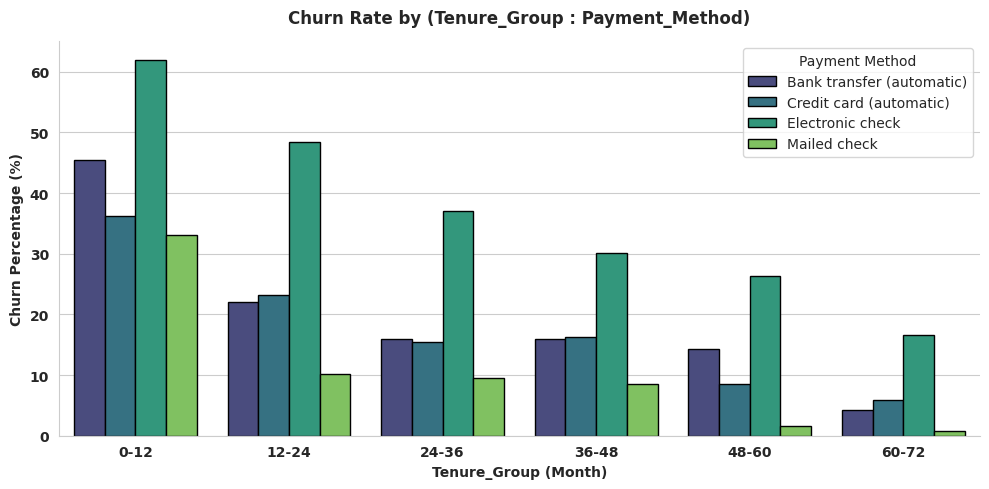

In [ ]:

plt.figure(figsize=(10,5))
sns.set_style("whitegrid")

sns.barplot(data = t_group, x='Tenure_Group', y='Churn_Percentage', hue='Payment_Method', palette='viridis', edgecolor = "black")

plt.title('Churn Rate by (Tenure_Group : Payment_Method)', fontsize=12, fontweight='bold', pad=13)
plt.ylabel('Churn Percentage (%)', fontsize=10, fontweight='bold')
plt.xlabel('Tenure_Group (Month)', fontsize=10, fontweight='bold')

plt.xticks(fontweight = "bold")
plt.yticks(fontweight = "bold")

plt.legend(title = "Payment Method")
sns.despine()

plt.tight_layout()
plt.show()

### **Insights**

- **Finding:** Across every tenure range, Electronic check consistently has the highest churn rate of all payment methods — confirming it's a real, independent risk factor and not just a byproduct of those customers being newer.
- **So What:** Switching a customer's payment method away from Electronic check could reduce churn risk on its own, regardless of how long they've been a customer or what contract they're on.
- **Recommendation:** The company should actively encourage Electronic check users to switch to automatic bank transfer or credit card payment — for example, through a small discount or incentive — since this is a targetable, low-effort lever that applies across the entire customer base, not just one segment.

# **4. Internet Service Type vs Churn**

**Problem Statement:** Does the type of internet service (DSL, Fiber optic, or none) affect churn rate? This helps determine whether the company's premium Fiber offering is retaining customers as expected, or losing them faster than lower-tier services.

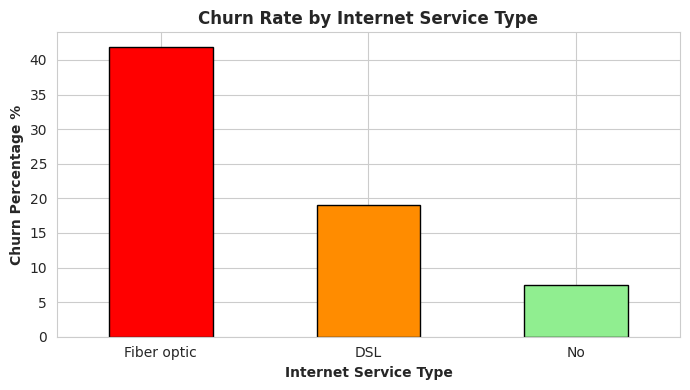

In [ ]:

# Calculating The Churn Rtatio

internet_service_churn = df.groupby("Internet_Service")["Churn_Flag"].mean().sort_values(ascending = False)*100


plt.figure(figsize=(7,4))

internet_service_churn.plot(kind="bar", color= ['red','darkorange',"lightgreen"], edgecolor = "black")
plt.title("Churn Rate by Internet Service Type", fontsize = 12, fontweight = "bold")
plt.xlabel("Internet Service Type", fontsize = 10, fontweight = "bold")
plt.ylabel("Churn Percentage %", fontsize = 10, fontweight = "bold")
plt.xticks(rotation = 0)

plt.tight_layout()
plt.show()



### **Insights**

Fiber optic customers churn at 40%+, more than double DSL's 20%, and far higher than customers with no internet service (~5%).

## **4.1 Follow-up Investigation: Is Fiber Optic's High Churn Really About the Product, or Explained by Something Else?**

Fiber optic customers showed ~40%+ churn vs DSL's ~20% — but this could be a genuine service/support gap (Fiber customers lacking Tech Support more often).

**Testing:** churn rate for Fiber optic customers with vs. without Tech Support, to see if support presence changes the picture.

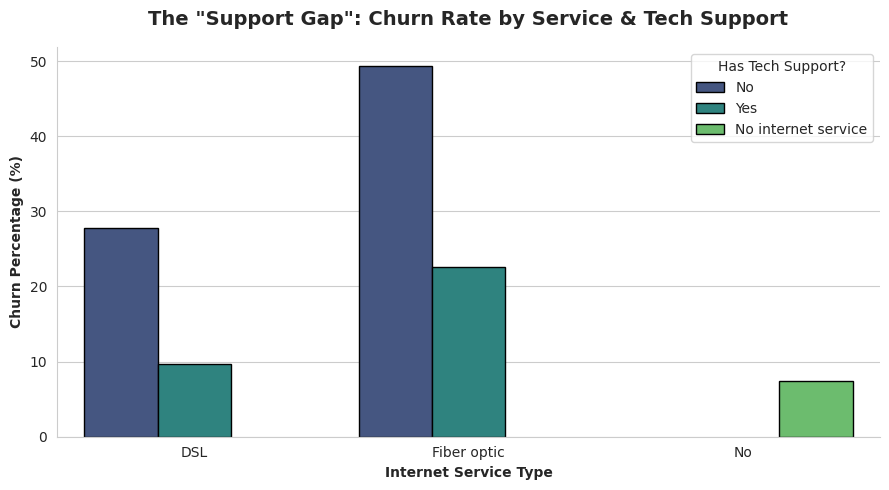

In [ ]:

plt.figure(figsize=(9, 5))
sns.set_style("whitegrid")

# Calculate the churn rate data
plot_data = df.groupby(['Internet_Service', 'Tech_Support'])['Churn_Flag'].mean().reset_index()
plot_data['Churn_Rate_%'] = plot_data['Churn_Flag'] * 100

sns.barplot(data=plot_data, x='Internet_Service', y='Churn_Rate_%', hue='Tech_Support', palette='viridis', edgecolor='black')

plt.title('The "Support Gap": Churn Rate by Service & Tech Support', fontsize=14, fontweight='bold', pad=16)
plt.ylabel('Churn Percentage (%)', fontsize=10, fontweight='bold')
plt.xlabel('Internet Service Type', fontsize=10, fontweight='bold')

plt.legend(title='Has Tech Support?')
sns.despine()

plt.tight_layout()
plt.show()

### **Insights**

- **Finding:** Within Fiber optic, customers without Tech Support churn at ~50%, versus ~23% for those with Tech Support — more than double. The same pattern holds for DSL (28% vs 10%), but Fiber's gap is by far the largest in absolute terms.
- **So What:** Fiber optic customers without Tech Support are the single highest-risk segment in the dataset (~50% churn) — nearly 1 in 2 leave. This suggests the "premium" Fiber product is genuinely underperforming for customers who aren't also paying for support — likely because Fiber has more complexity or reliability issues that unsupported customers can't resolve on their own.
- **Recommendation:** The company should prioritize offering Tech Support (potentially bundled or discounted) specifically to Fiber optic customers, since this segment shows the largest churn-reduction opportunity of any factor tested — cutting churn roughly in half within this group alone.

## **4.2 Follow-up Investigation: Does Tech Support Matter More for Senior Citizens?**

**Problem Statement:** Tech Support was already shown to reduce churn overall (the "Toxic Product" finding). The next question is whether this effect is the same for everyone, or whether some groups benefit more from Tech Support than others — specifically, do Senior Citizens without Tech Support churn even more than non-seniors without Tech Support?

In [ ]:

# Make a new column that shows senior  as yes and no easy to understand

df['Senior_Citizen_Status'] = np.where(df["Senior_Citizen"] == 1, "Yes","No")


In [ ]:

Seniour_Churn = df.groupby(["Senior_Citizen_Status","Tech_Support"])["Churn_Flag"].mean().reset_index()

Seniour_Churn["Churn_Percentage"] = Seniour_Churn["Churn_Flag"]*100

Seniour_Churn

,Senior_Citizen_Status,Tech_Support,Churn_Flag,Churn_Percentage
0,No,No,0.388342,38.834217
1,No,No internet service,0.073569,7.356948
2,No,Yes,0.145506,14.550562
3,Yes,No,0.506024,50.602410
4,Yes,No internet service,0.096154,9.615385
5,Yes,Yes,0.196154,19.615385


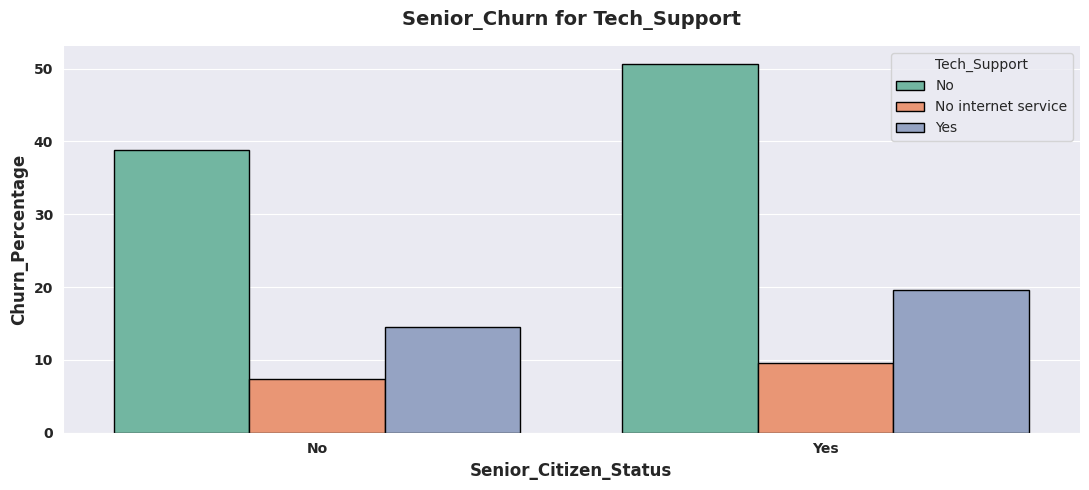

In [ ]:

plot(Seniour_Churn,"Senior_Citizen_Status","Churn_Percentage","Tech_Support","Senior_Churn for Tech_Support",
          'Senior_Citizen_Status', 'Churn_Percentage', "Tech_Support")

### **Insights**

- **Finding:** Senior Citizens churn more than non-seniors in every Tech Support category, but the gap is largest when Tech Support is missing — 51% churn for seniors without support vs. 39% for non-seniors without support (a 12-point gap), compared to only a 5-point gap when Tech Support is present (20% vs 15%).
- **So What:** Seniors appear to be hit harder by the absence of Tech Support than younger customers are — though this chart shows the pattern, not the reason (e.g. seniors may struggle more with self-troubleshooting).

- **Recommendation:** When rolling out the Tech Support bundling recommendation made earlier, the company should prioritize Senior Citizens first, since this segment shows the largest churn-reduction opportunity from adding support.